In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import joblib

In [3]:
df = pd.read_csv('../data/processed/cleaned_train.csv')

# Prepare features and target variable
# Select only numeric columns (excluding target variable)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col != 'SalePrice']
X = df[feature_cols]
y = df['SalePrice']

print(f"Features shape: {X.shape}")
print(f"Numeric features: {feature_cols}")

Features shape: (441, 37)
Numeric features: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [4]:
# split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% training and 20% test, random state for reproducibility (42 is a common choice  but can be any integer)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 352
Test set size: 89


In [5]:
# scale features (uses z-score standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model training completed.")





Model training completed.


In [6]:
# make predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print("Model prediction completed.")


Model prediction completed.


In [7]:
# evaluate the model
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("\nModel Performance:")
print(f"Training RMSE: {train_rmse}")
print(f"Test RMSE: {test_rmse}")
print(f"Training R-squared: {train_r2}")
print(f"Test R-squared: {test_r2}")
print(f"Test MAE: {test_mae}")


Model Performance:
Training RMSE: 32895.00852537798
Test RMSE: 35293.23021999068
Training R-squared: 0.8108540326165198
Test R-squared: 0.6931400171257907
Test MAE: 25763.77003046596


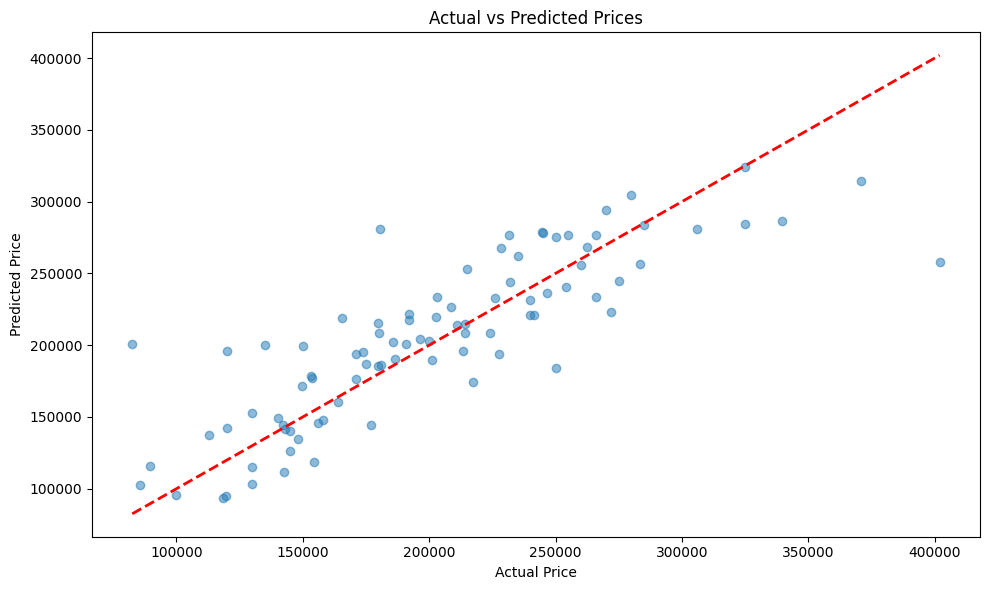

In [8]:
# Visualize predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.tight_layout()
plt.show()

In [9]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model.coef_
}).sort_values('coefficient', ascending=False)

print("\nFeature Importance (Coefficients):")
print(feature_importance)


Feature Importance (Coefficients):
          feature   coefficient
4     OverallQual  3.328934e+04
26     GarageCars  8.867129e+03
6       YearBuilt  8.119190e+03
28     WoodDeckSF  7.871451e+03
27     GarageArea  7.499817e+03
31      3SsnPorch  7.278261e+03
24     Fireplaces  7.275034e+03
17   BsmtFullBath  6.901749e+03
23   TotRmsAbvGrd  6.529107e+03
7    YearRemodAdd  5.962237e+03
8      MasVnrArea  5.028893e+03
21   BedroomAbvGr  4.848244e+03
32    ScreenPorch  3.842631e+03
29    OpenPorchSF  2.374610e+03
20       HalfBath  2.271188e+03
16      GrLivArea  2.248792e+03
13       1stFlrSF  2.194680e+03
9      BsmtFinSF1  1.496771e+03
10     BsmtFinSF2  5.726418e+02
14       2ndFlrSF  4.550720e+02
5     OverallCond  3.865875e+02
35         MoSold  3.187615e+02
30  EnclosedPorch  8.721003e+01
15   LowQualFinSF -5.115908e-13
34        MiscVal -3.050809e+02
2     LotFrontage -4.436315e+02
18   BsmtHalfBath -4.632530e+02
12    TotalBsmtSF -1.062171e+03
25    GarageYrBlt -1.643516e+03
0   

In [ ]:
# Save model and scaler
with open('../models/linear_regression_model.pkl', 'wb') as f:
    joblib.dump(model, f)

with open('../models/scaler.pkl', 'wb') as f:
    joblib.dump(scaler, f)

print("\nModel and scaler saved!")


Model and scaler saved!
